In [9]:
import os
import glob
import random

base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_3classes"

def count_and_split(folder_path):
    
    subfolders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]
    
    all_data = {}
    
    for sub in subfolders:
        
        images = glob.glob(os.path.join(folder_path, sub, "*.*"))
        random.shuffle(images)
        split_idx = int(len(images) * 0.8)
        train_set = images[:split_idx]
        test_set = images[split_idx:]
        
        all_data[sub] = {"train": train_set, "test": test_set}
        print(f"Folder {sub}: Found {len(images)} total. Training: {len(train_set)}, Testing: {len(test_set)}")

count_and_split(base_path)

Folder HV: Found 4280 total. Training: 3424, Testing: 856
Folder LV: Found 280 total. Training: 224, Testing: 56
Folder MV: Found 560 total. Training: 448, Testing: 112


In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = models.resnet18(pretrained=True).to(device)
model.fc = nn.Identity() 
model.eval()


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_features(img_path):
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = model(img)
    return feature.cpu()



Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:02<00:00, 23.2MB/s]


In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import glob
import random


base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Arousal_PR_2classes"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = models.resnet18(pretrained=True).to(device)
model.fc = nn.Identity() 
model.eval()


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


train_features, train_labels = [], []
test_features, test_labels = [], []

subfolders = {'HA': 1, 'LA': 0} 

for sub, label in subfolders.items():
    folder_path = os.path.join(base_path, sub)
    images = glob.glob(os.path.join(folder_path, "*.*"))
    random.shuffle(images)
    
    split_idx = int(len(images) * 0.8)
    train_files = images[:split_idx]
    test_files = images[split_idx:]
    
    print(f"Processing {sub}...")
    
    
    for img_path in train_files:
        img = Image.open(img_path).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model(img_t)
        train_features.append(feat.cpu())
        train_labels.append(label)

    for img_path in test_files:
        img = Image.open(img_path).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model(img_t)
        test_features.append(feat.cpu())
        test_labels.append(label)

save_data = {
    'x_train': torch.cat(train_features),
    'y_train': torch.tensor(train_labels),
    'x_test': torch.cat(test_features),
    'y_test': torch.tensor(test_labels)
}

torch.save(save_data, 'processed_data.pt')
print("\n--- DONE! ---")
print(f"Saved {len(train_labels)} training nodes and {len(test_labels)} testing nodes to 'processed_data.pt'")

Processing HA...
Processing LA...

--- DONE! ---
Saved 4104 training nodes and 1026 testing nodes to 'processed_data.pt'


In [9]:
import torch
from torch_geometric.data import Data


data_dict = torch.load('processed_data.pt')


def manual_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

print("Building Web (Training)...")
train_edges = manual_knn(data_dict['x_train'])

print("Building Web (Testing)...")
test_edges = manual_knn(data_dict['x_test'])


train_data = Data(x=data_dict['x_train'], edge_index=train_edges, y=data_dict['y_train'])
test_data = Data(x=data_dict['x_test'], edge_index=test_edges, y=data_dict['y_test'])

print("\n--- DONE! Web Created! ---")
print(f"Training: {train_data.num_edges} edges")
print(f"Testing: {test_data.num_edges} edges")

torch.save({'train': train_data, 'test': test_data}, 'graph_data.pt')

Building Web (Training)...
Building Web (Testing)...

--- DONE! Web Created! ---
Training: 20520 edges
Testing: 5130 edges


Loading graph data...

Starting Training...
Epoch 000, Loss: 0.9417
Epoch 020, Loss: 0.6578
Epoch 040, Loss: 0.6051
Epoch 060, Loss: 0.5843
Epoch 080, Loss: 0.5726
Epoch 100, Loss: 0.5660
Epoch 120, Loss: 0.5644
Epoch 140, Loss: 0.5595
Epoch 160, Loss: 0.5596
Epoch 180, Loss: 0.5585

      AROUSAL FINAL REPORT
              precision    recall  f1-score   support

         Low       0.56      0.80      0.66       450
        High       0.77      0.51      0.62       576

    accuracy                           0.64      1026
   macro avg       0.67      0.66      0.64      1026
weighted avg       0.68      0.64      0.64      1026

ROC AUC Score: 0.7024


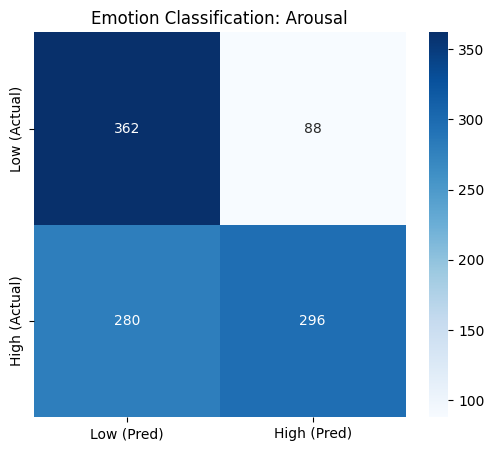

In [12]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading graph data...")

graphs = torch.load('graph_data.pt', weights_only=False)
train_data = graphs['train']
test_data = graphs['test']


train_data.y = train_data.y.long()
test_data.y = test_data.y.long()


class GNN(torch.nn.Module):
    def __init__(self):
        super(GNN, self).__init__()
        
        self.conv1 = GCNConv(512, 128) 
        
        self.conv2 = GCNConv(128, 2)   

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training) # Helps prevent overfitting
        
        
        x = self.conv2(x, edge_index)
        
        return F.log_softmax(x, dim=1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNN().to(device)
train_data = train_data.to(device)
test_data = test_data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)


print("\nStarting Training...")
model.train()
for epoch in range(200): 
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')


model.eval()
with torch.no_grad():
    logits = model(test_data)
    pred = logits.argmax(dim=1)
    
    y_true = test_data.y.cpu()
    y_pred = pred.cpu()
    
    probs = torch.exp(logits)[:, 1].cpu()

    print("\n" + "="*30)
    print("      AROUSAL FINAL REPORT")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=['Low', 'High']))
    
    auc = roc_auc_score(y_true, probs)
    print(f"ROC AUC Score: {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low (Pred)', 'High (Pred)'], 
                yticklabels=['Low (Actual)', 'High (Actual)'])
    plt.title('Emotion Classification: Arousal')
    plt.show()

Loading graph data for Improved GNN...
Starting Advanced Training (GAT)...
Epoch 000, Loss: 0.9892
Epoch 020, Loss: 0.6145
Epoch 040, Loss: 0.5801
Epoch 060, Loss: 0.5617
Epoch 080, Loss: 0.5386
Epoch 100, Loss: 0.5408
Epoch 120, Loss: 0.5312
Epoch 140, Loss: 0.5167
Epoch 160, Loss: 0.5086
Epoch 180, Loss: 0.4988

   IMPROVED AROUSAL REPORT (GAT)
              precision    recall  f1-score   support

         Low       0.64      0.15      0.24       450
        High       0.58      0.94      0.72       576

    accuracy                           0.59      1026
   macro avg       0.61      0.54      0.48      1026
weighted avg       0.61      0.59      0.51      1026

ROC AUC Score: 0.7144


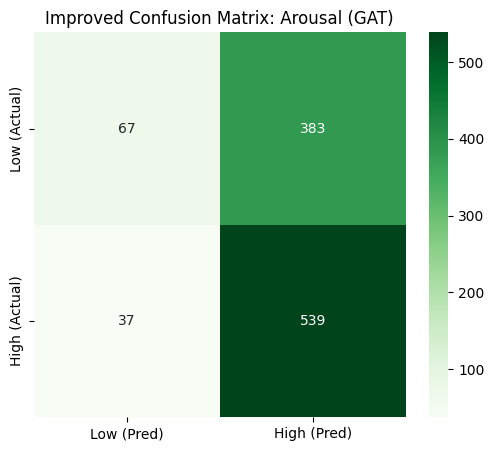

In [13]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, BatchNorm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading graph data for Improved GNN...")
graphs = torch.load('graph_data.pt', weights_only=False)
train_data = graphs['train']
test_data = graphs['test']

train_data.y = train_data.y.long()
test_data.y = test_data.y.long()

class ImprovedGNN(torch.nn.Module):
    def __init__(self):
        super(ImprovedGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True) 
        self.bn1 = BatchNorm(128 * 4)
        
        self.conv2 = GATv2Conv(128 * 4, 2, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x) 
        x = F.dropout(x, p=0.4, training=self.training)
        
        # Second Layer
        x = self.conv2(x, edge_index)
        
        return F.log_softmax(x, dim=1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedGNN().to(device)
train_data = train_data.to(device)
test_data = test_data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print("Starting Advanced Training (GAT)...")
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    logits = model(test_data)
    pred = logits.argmax(dim=1)
    
    y_true = test_data.y.cpu()
    y_pred = pred.cpu()
    probs = torch.exp(logits)[:, 1].cpu()

    print("\n" + "="*30)
    print("   IMPROVED AROUSAL REPORT (GAT)")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=['Low', 'High']))
    
    auc = roc_auc_score(y_true, probs)
    print(f"ROC AUC Score: {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Low (Pred)', 'High (Pred)'], 
                yticklabels=['Low (Actual)', 'High (Actual)'])
    plt.title('Improved Confusion Matrix: Arousal (GAT)')
    plt.show()

In [16]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import glob

base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_2classes"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(pretrained=True).to(device)
model.fc = nn.Identity()
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


train_features, train_labels = [], []
test_features, test_labels = [], []


subfolders = {'HV': 1, 'LV': 0}

for sub, label in subfolders.items():
    folder_path = os.path.join(base_path, sub)
    images = glob.glob(os.path.join(folder_path, "*.*"))
    
    split_idx = int(len(images) * 0.8)
    train_files = images[:split_idx]
    test_files = images[split_idx:]
    
    print(f"Scanning {sub}...")
    for img_path in train_files:
        img = Image.open(img_path).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model(img_t)
        train_features.append(feat.cpu())
        train_labels.append(label)

    for img_path in test_files:
        img = Image.open(img_path).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model(img_t)
        test_features.append(feat.cpu())
        test_labels.append(label)

save_data = {
    'x_train': torch.cat(train_features),
    'y_train': torch.tensor(train_labels),
    'x_test': torch.cat(test_features),
    'y_test': torch.tensor(test_labels)
}
torch.save(save_data, 'processed_data.pt')
print("\n--- DONE! Valence Math Saved ---")

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Scanning HV...
Scanning LV...

--- DONE! Valence Math Saved ---


In [17]:
import torch
from torch_geometric.data import Data

data_dict = torch.load('processed_data.pt', weights_only=False)

def manual_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

print("Building Valence Web (Training)...")
train_edges = manual_knn(data_dict['x_train'])

print("Building Valence Web (Testing)...")
test_edges = manual_knn(data_dict['x_test'])

train_data = Data(x=data_dict['x_train'], edge_index=train_edges, y=data_dict['y_train'])
test_data = Data(x=data_dict['x_test'], edge_index=test_edges, y=data_dict['y_test'])

print("\n--- DONE! Valence Web Created! ---")
print(f"Training: {train_data.num_edges} edges")
print(f"Testing: {test_data.num_edges} edges")

torch.save({'train': train_data, 'test': test_data}, 'graph_data.pt')

Building Valence Web (Training)...
Building Valence Web (Testing)...

--- DONE! Valence Web Created! ---
Training: 20480 edges
Testing: 5120 edges


Loading Valence graph data for Weighted GAT...
Applying Class Weights: Low=11.80, High=1.00
Training on Valence with Class Balancing...
Epoch 000, Loss: 0.8781
Epoch 020, Loss: 0.6183
Epoch 040, Loss: 0.5609
Epoch 060, Loss: 0.5393
Epoch 080, Loss: 0.5035
Epoch 100, Loss: 0.4732
Epoch 120, Loss: 0.4365
Epoch 140, Loss: 0.4210
Epoch 160, Loss: 0.3850
Epoch 180, Loss: 0.3491

   WEIGHTED VALENCE FINAL REPORT
              precision    recall  f1-score   support

 Low Valence       0.18      0.47      0.26        80
High Valence       0.95      0.82      0.88       944

    accuracy                           0.79      1024
   macro avg       0.57      0.65      0.57      1024
weighted avg       0.89      0.79      0.83      1024

ROC AUC Score: 0.7677


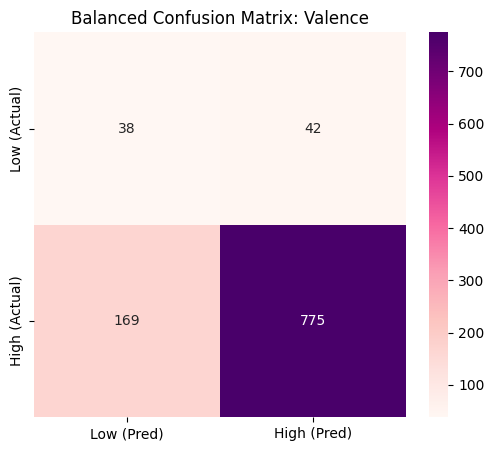

In [19]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, BatchNorm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading Valence graph data for Weighted GAT...")
graphs = torch.load('graph_data.pt', weights_only=False)
train_data = graphs['train']
test_data = graphs['test']

train_data.y = train_data.y.long()
test_data.y = test_data.y.long()


count_low = (train_data.y == 0).sum().item()
count_high = (train_data.y == 1).sum().item()
weight_for_low = count_high / count_low

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights = torch.tensor([weight_for_low, 1.0]).to(device)
print(f"Applying Class Weights: Low={weight_for_low:.2f}, High=1.00")


class WeightedValenceGNN(torch.nn.Module):
    def __init__(self):
        super(WeightedValenceGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True) 
        self.bn1 = BatchNorm(128 * 4)
        self.conv2 = GATv2Conv(128 * 4, 2, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


model = WeightedValenceGNN().to(device)
train_data = train_data.to(device)
test_data = test_data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print("Training on Valence with Class Balancing...")
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = model(train_data)
    
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    logits = model(test_data)
    pred = logits.argmax(dim=1)
    y_true = test_data.y.cpu()
    y_pred = pred.cpu()
    probs = torch.exp(logits)[:, 1].cpu()

    print("\n" + "="*30)
    print("   WEIGHTED VALENCE FINAL REPORT")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=['Low Valence', 'High Valence']))
    print(f"ROC AUC Score: {roc_auc_score(y_true, probs):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
                xticklabels=['Low (Pred)', 'High (Pred)'], 
                yticklabels=['Low (Actual)', 'High (Actual)'])
    plt.title('Balanced Confusion Matrix: Valence')
    plt.show()

--- STAGE 1: Scanning Dominance Images ---
Processing HD folder...
Processing LD folder...

--- STAGE 2: Building the Web (KNN) ---

--- STAGE 3: Training Weighted GAT ---
Epoch 000, Loss: 0.9192
Epoch 050, Loss: 0.5112
Epoch 100, Loss: 0.4890
Epoch 150, Loss: 0.4575
Epoch 200, Loss: 0.4254
Epoch 250, Loss: 0.3852

--- STAGE 4: Final Results ---
              precision    recall  f1-score   support

     Low Dom       0.60      0.81      0.69       194
    High Dom       0.95      0.87      0.91       832

    accuracy                           0.86      1026
   macro avg       0.77      0.84      0.80      1026
weighted avg       0.89      0.86      0.87      1026

ROC AUC Score: 0.8991


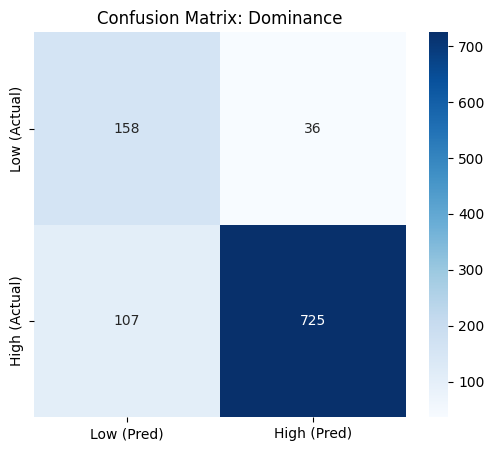

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os
import glob
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_PR_2classes"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("--- STAGE 1: Scanning Dominance Images ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_features, train_labels = [], []
test_features, test_labels = [], []
subfolders = {'HD': 1, 'LD': 0} # High Dominance = 1, Low = 0

for sub, label in subfolders.items():
    folder_path = os.path.join(base_path, sub)
    images = glob.glob(os.path.join(folder_path, "*.*"))
    split_idx = int(len(images) * 0.8)
    
    print(f"Processing {sub} folder...")
    for i, img_path in enumerate(images):
        img = Image.open(img_path).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model_ft(img_t)
        
        if i < split_idx:
            train_features.append(feat.cpu())
            train_labels.append(label)
        else:
            test_features.append(feat.cpu())
            test_labels.append(label)

x_train = torch.cat(train_features)
y_train = torch.tensor(train_labels).long()
x_test = torch.cat(test_features)
y_test = torch.tensor(test_labels).long()


print("\n--- STAGE 2: Building the Web (KNN) ---")
def manual_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_edges = manual_knn(x_train)
test_edges = manual_knn(x_test)

train_data = Data(x=x_train, edge_index=train_edges, y=y_train).to(device)
test_data = Data(x=x_test, edge_index=test_edges, y=y_test).to(device)

print("\n--- STAGE 3: Training Weighted GAT ---")
count_low = (y_train == 0).sum().item()
count_high = (y_train == 1).sum().item()
weight_for_low = count_high / count_low
class_weights = torch.tensor([weight_for_low, 1.0]).to(device)

class DominanceGNN(torch.nn.Module):
    def __init__(self):
        super(DominanceGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True) 
        self.bn1 = BatchNorm(128 * 4)
        self.conv2 = GATv2Conv(128 * 4, 2, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = DominanceGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

class_weights = torch.tensor([15.0, 1.0]).to(device) 

model.train()
for epoch in range(300): 
    optimizer.zero_grad()
    out = model(train_data)
    
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

print("\n--- STAGE 4: Final Results ---")
model.eval()
with torch.no_grad():
    logits = model(test_data)
    pred = logits.argmax(dim=1)
    y_true, y_pred = test_data.y.cpu(), pred.cpu()
    probs = torch.exp(logits)[:, 1].cpu()

    print(classification_report(y_true, y_pred, target_names=['Low Dom', 'High Dom']))
    print(f"ROC AUC Score: {roc_auc_score(y_true, probs):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low (Pred)', 'High (Pred)'], 
                yticklabels=['Low (Actual)', 'High (Actual)'])
    plt.title('Confusion Matrix: Dominance')
    plt.show()

--- STAGE 1: Scanning 3-Class Valence ---
--- STAGE 2: Building 3-Class Web ---
--- STAGE 3: Training 3-Class Weighted GNN ---

   3-CLASS VALENCE REPORT
              precision    recall  f1-score   support

         Low       0.17      0.12      0.14        56
         Mid       0.31      0.28      0.29       112
        High       0.87      0.90      0.89       856

    accuracy                           0.79      1024
   macro avg       0.45      0.43      0.44      1024
weighted avg       0.77      0.79      0.78      1024



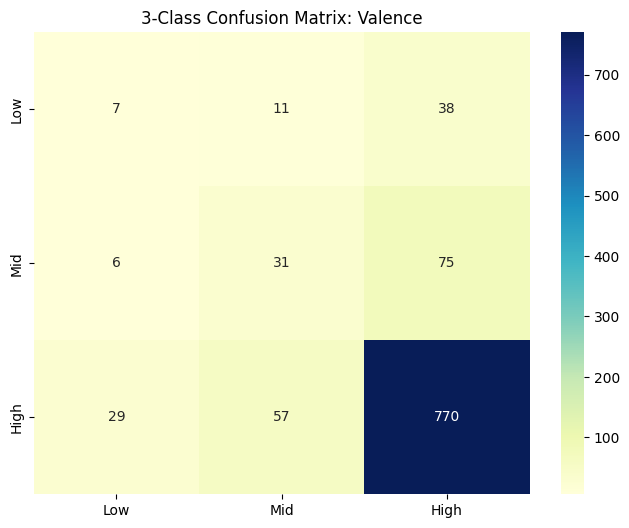

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os
import glob
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_3classes"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


print("--- STAGE 1: Scanning 3-Class Valence ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_features, train_labels = [], []
test_features, test_labels = [], []
# Mapping folders to numbers: Low=0, Mid=1, High=2
subfolders = {'LV': 0, 'MV': 1, 'HV': 2} 

for sub, label in subfolders.items():
    folder_path = os.path.join(base_path, sub)
    images = glob.glob(os.path.join(folder_path, "*.*"))
    split_idx = int(len(images) * 0.8)
    
    for i, img_path in enumerate(images):
        img = Image.open(img_path).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model_ft(img_t)
        
        if i < split_idx:
            train_features.append(feat.cpu())
            train_labels.append(label)
        else:
            test_features.append(feat.cpu())
            test_labels.append(label)

x_train, y_train = torch.cat(train_features), torch.tensor(train_labels).long()
x_test, y_test = torch.cat(test_features), torch.tensor(test_labels).long()


print("--- STAGE 2: Building 3-Class Web ---")
def manual_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=manual_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=manual_knn(x_test), y=y_test).to(device)


class_weights = torch.tensor([15.0, 8.0, 1.0]).to(device) 

class MultiClassGNN(torch.nn.Module):
    def __init__(self):
        super(MultiClassGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True)
        self.bn1 = BatchNorm(128 * 4)
        self.conv2 = GATv2Conv(128 * 4, 3, heads=1, concat=False) 

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = MultiClassGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("--- STAGE 3: Training 3-Class Weighted GNN ---")
model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()


model.eval()
with torch.no_grad():
    pred = model(test_data).argmax(dim=1).cpu()
    print("\n" + "="*30)
    print("   3-CLASS VALENCE REPORT")
    print("="*30)
    print(classification_report(y_test, pred, target_names=['Low', 'Mid', 'High']))
    
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
    plt.title('3-Class Confusion Matrix: Valence')
    plt.show()

--- STAGE 1: Scanning 3-Class Dominance ---
Processing LD: Found 1920 images...
Processing MD: Found 1746 images...
Processing HD: Found 6560 images...

--- STAGE 2: Building 3-Class Web ---

--- STAGE 3: Training Weighted GNN ---
Epoch 000, Loss: 1.3194
Epoch 050, Loss: 0.8608
Epoch 100, Loss: 0.7846
Epoch 150, Loss: 0.6996
Epoch 200, Loss: 0.6257
Epoch 250, Loss: 0.5557

   FINAL 3-CLASS DOMINANCE REPORT
              precision    recall  f1-score   support

         Low       0.39      0.88      0.54       384
         Mid       0.52      0.24      0.33       350
        High       0.98      0.76      0.86      1312

    accuracy                           0.70      2046
   macro avg       0.63      0.63      0.58      2046
weighted avg       0.79      0.70      0.71      2046



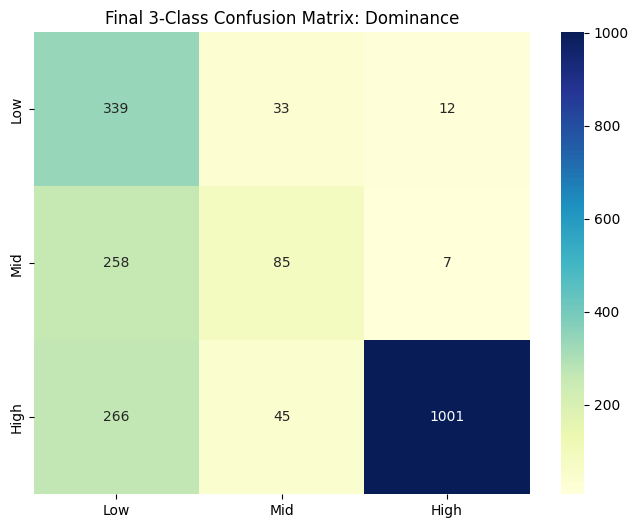

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os
import glob
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_P_3Clases"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("--- STAGE 1: Scanning 3-Class Dominance ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_features, train_labels = [], []
test_features, test_labels = [], []
subfolders = {'LD': 0, 'MD': 1, 'HD': 2} 

for sub, label in subfolders.items():
    folder_path = os.path.join(base_path, sub)
    
    images = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.JPG", "*.PNG"]:
        images.extend(glob.glob(os.path.join(folder_path, ext)))
    
    if not images:
        print(f"⚠️ WARNING: No images found in {folder_path}. Please check the folder name.")
        continue

    split_idx = int(len(images) * 0.8)
    print(f"Processing {sub}: Found {len(images)} images...")
    
    for i, img_path in enumerate(images):
        try:
            img = Image.open(img_path).convert('RGB')
            img_t = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = model_ft(img_t)
            
            if i < split_idx:
                train_features.append(feat.cpu())
                train_labels.append(label)
            else:
                test_features.append(feat.cpu())
                test_labels.append(label)
        except Exception as e:
            continue

if not train_features:
    raise ValueError("No images were successfully scanned. Check your 'base_path'.")

x_train, y_train = torch.cat(train_features), torch.tensor(train_labels).long()
x_test, y_test = torch.cat(test_features), torch.tensor(test_labels).long()

print("\n--- STAGE 2: Building 3-Class Web ---")
def manual_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=manual_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=manual_knn(x_test), y=y_test).to(device)

class_weights = torch.tensor([12.0, 6.0, 1.0]).to(device) 

class FinalDominanceGNN(torch.nn.Module):
    def __init__(self):
        super(FinalDominanceGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True)
        self.bn1 = BatchNorm(128 * 4)
        self.conv2 = GATv2Conv(128 * 4, 3, heads=1, concat=False) 

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = FinalDominanceGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\n--- STAGE 3: Training Weighted GNN ---")
model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    pred = model(test_data).argmax(dim=1).cpu()
    print("\n" + "="*30)
    print("   FINAL 3-CLASS DOMINANCE REPORT")
    print("="*30)
    print(classification_report(y_test, pred, target_names=['Low', 'Mid', 'High']))
    
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
    plt.title('Final 3-Class Confusion Matrix: Dominance')
    plt.show()

--- STAGE 1: Scanning (Safe Batch Mode) ---
Processing LV...
Processing MV...
Processing HV...
--- STAGE 2: Building 3-Class KNN Graph ---
--- STAGE 3: Training ---
Epoch 000, Loss: 1.4752
Epoch 050, Loss: 0.9062
Epoch 100, Loss: 0.7607
Epoch 150, Loss: 0.6326
Epoch 200, Loss: 0.5156
Epoch 250, Loss: 0.4098
--- STAGE 4: Final Evaluation ---
              precision    recall  f1-score   support

         Low       0.13      0.03      0.05        70
         Mid       0.16      0.30      0.21       140
        High       0.85      0.79      0.82      1070

    accuracy                           0.70      1280
   macro avg       0.38      0.37      0.36      1280
weighted avg       0.73      0.70      0.71      1280



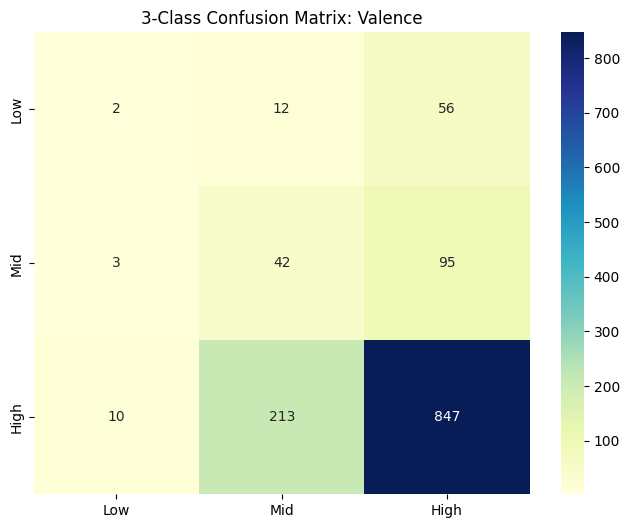

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os
import glob
import gc
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_3classes"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16  # Keeps your VRAM from overflowing


print("--- STAGE 1: Scanning (Safe Batch Mode) ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def safe_scan():
    train_feats, train_labs = [], []
    test_feats, test_labs = [], []
    subfolders = {'LV': 0, 'MV': 1, 'HV': 2}

    for sub, label in subfolders.items():
        folder_path = os.path.join(base_path, sub)
        images = glob.glob(os.path.join(folder_path, "*.*"))
        if not images: continue
        
        print(f"Processing {sub}...")
        for i in range(0, len(images), BATCH_SIZE):
            batch_paths = images[i:i + BATCH_SIZE]
            batch_tensors = []
            
            for p in batch_paths:
                try:
                    with Image.open(p) as img:
                        batch_tensors.append(transform(img.convert('RGB')))
                except: continue
            
            if not batch_tensors: continue
            
            input_batch = torch.stack(batch_tensors).to(device)
            with torch.no_grad():
                feats = model_ft(input_batch).cpu()
            
            split = int(len(feats) * 0.8)
            train_feats.append(feats[:split])
            test_feats.append(feats[split:])
            train_labs.extend([label] * len(feats[:split]))
            test_labs.extend([label] * len(feats[split:]))

            # Memory Cleanup
            del input_batch, feats
            torch.cuda.empty_cache()
            if i % 400 == 0: gc.collect()

    return torch.cat(train_feats), torch.tensor(train_labs), \
           torch.cat(test_feats), torch.tensor(test_labs)

x_train, y_train, x_test, y_test = safe_scan()


print("--- STAGE 2: Building 3-Class KNN Graph ---")
def build_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=build_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=build_knn(x_test), y=y_test).to(device)


class_weights = torch.tensor([15.0, 8.0, 1.0]).to(device)

class Valence3ClassGNN(torch.nn.Module):
    def __init__(self):
        super(Valence3ClassGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True)
        self.bn1 = BatchNorm(128 * 4)
        self.conv2 = GATv2Conv(128 * 4, 3, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.4, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = Valence3ClassGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("--- STAGE 3: Training ---")
model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

print("--- STAGE 4: Final Evaluation ---")
model.eval()
with torch.no_grad():
    pred = model(test_data).argmax(dim=1).cpu()
    y_true = test_data.y.cpu()
    print(classification_report(y_true, pred, target_names=['Low', 'Mid', 'High']))
    
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
    plt.title('3-Class Confusion Matrix: Valence')
    plt.show()

In [6]:
import os
base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_P_3Clases"

if not os.path.exists(base_path):
    print("❌ ERROR: The path does not exist. Check your drive connection.")
else:
    content = os.listdir(base_path)
    print(f"✅ Path found! Content: {content}")
    for item in content:
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            files = os.listdir(item_path)
            print(f"   📁 Folder '{item}' contains {len(files)} files.")

✅ Path found! Content: ['HD', 'LD', 'MD']
   📁 Folder 'HD' contains 3280 files.
   📁 Folder 'LD' contains 960 files.
   📁 Folder 'MD' contains 873 files.


--- STAGE 1: Scanning Dominance ---
Processing LD: 1920 images found.
Processing MD: 1746 images found.
Processing HD: 6560 images found.
--- STAGE 2: Building KNN Graph ---
--- STAGE 3: Training ---
Epoch 000, Loss: 1.3418
Epoch 050, Loss: 0.9094
Epoch 100, Loss: 0.8227
Epoch 150, Loss: 0.7369
Epoch 200, Loss: 0.6360
Epoch 250, Loss: 0.5550
--- STAGE 4: Final Evaluation ---
              precision    recall  f1-score   support

    Low (LD)       0.25      0.16      0.20       480
    Mid (MD)       0.24      0.73      0.36       437
   High (HD)       0.76      0.42      0.54      1640

    accuracy                           0.42      2557
   macro avg       0.42      0.44      0.36      2557
weighted avg       0.58      0.42      0.44      2557



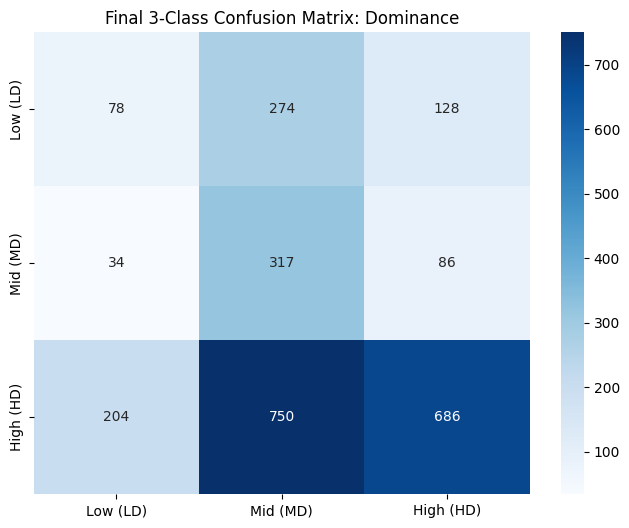

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os
import glob
import gc
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_P_3Clases"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16 

print("--- STAGE 1: Scanning Dominance ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def safe_scan():
    train_feats, train_labs = [], []
    test_feats, test_labs = [], []
    
    subfolders = {'LD': 0, 'MD': 1, 'HD': 2}

    for sub, label in subfolders.items():
        folder_path = os.path.join(base_path, sub)
        images = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.JPG", "*.PNG"]:
            images.extend(glob.glob(os.path.join(folder_path, ext)))
        
        if not images: 
            print(f"⚠️ Warning: No images found in {sub}")
            continue
        
        print(f"Processing {sub}: {len(images)} images found.")
        for i in range(0, len(images), BATCH_SIZE):
            batch_paths = images[i:i + BATCH_SIZE]
            batch_tensors = []
            
            for p in batch_paths:
                try:
                    with Image.open(p) as img:
                        batch_tensors.append(transform(img.convert('RGB')))
                except: continue
            
            if not batch_tensors: continue
            
            input_batch = torch.stack(batch_tensors).to(device)
            with torch.no_grad():
                feats = model_ft(input_batch).cpu()
            
            split = int(len(feats) * 0.8)
            train_feats.append(feats[:split])
            test_feats.append(feats[split:])
            train_labs.extend([label] * len(feats[:split]))
            test_labs.extend([label] * len(feats[split:]))

            del input_batch, feats
            torch.cuda.empty_cache()
            if i % 400 == 0: gc.collect()

    return torch.cat(train_feats), torch.tensor(train_labs), \
           torch.cat(test_feats), torch.tensor(test_labs)

x_train, y_train, x_test, y_test = safe_scan()

# --- 3. GRAPH ARCHITECT ---
print("--- STAGE 2: Building KNN Graph ---")
def build_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=build_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=build_knn(x_test), y=y_test).to(device)

class_weights = torch.tensor([3.5, 3.8, 1.0]).to(device)

class Dominance3ClassGNN(torch.nn.Module):
    def __init__(self):
        super(Dominance3ClassGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True)
        self.bn1 = BatchNorm(128 * 4)
        self.conv2 = GATv2Conv(128 * 4, 3, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.4, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = Dominance3ClassGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("--- STAGE 3: Training ---")
model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

print("--- STAGE 4: Final Evaluation ---")
model.eval()
with torch.no_grad():
    pred = model(test_data).argmax(dim=1).cpu()
    y_true = test_data.y.cpu()
    names = ['Low (LD)', 'Mid (MD)', 'High (HD)']
    print(classification_report(y_true, pred, target_names=names))
    
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
    plt.title('Final 3-Class Confusion Matrix: Dominance')
    plt.show()